In [14]:
#Importing the required libraries 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [15]:
#load the dataset 
d=pd.read_csv("knn_regression_dataset.csv")
d

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404
...,...,...,...,...,...,...,...
995,60,NaN,272663.033166,502.604714,Chennai,Salaried,155285.942941
996,64,36687.617333,133069.710014,730.751324,Bangalore,Self-Employed,65076.404995
997,62,43438.125495,234645.931152,747.044458,Hyderabad,Unemployed,126006.462108
998,35,60835.720367,169706.958962,628.847359,Bangalore,Unemployed,118101.789665


In [16]:
d.isnull().sum()


age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

In [17]:
d.describe()

,age,income,loan_amount,credit_score,target
count,1000.00000,970.000000,970.000000,971.000000,1000.000000
mean,43.81900,52924.860515,204508.531872,649.422223,125258.332699
std,14.99103,21236.060048,58239.083910,71.104784,31423.294558
min,18.00000,6556.169327,49024.392209,440.620482,40800.918241
25%,31.00000,40854.271568,168890.053957,600.334270,105707.679044
50%,44.00000,51119.925190,200190.693629,649.978043,123651.542971
75%,56.00000,61104.364633,235458.241233,696.092859,141801.468844
max,69.00000,220985.397589,597644.058452,858.968130,333440.450713


<Axes: >

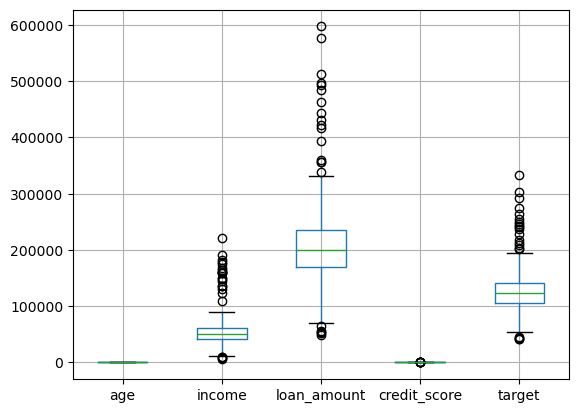

In [23]:
d.boxplot()

In [24]:
m1=d["income"].median()
m1

51119.92518950612

In [25]:
d["income"].fillna(m1,inplace=True)
d["income"]

C:\Users\akshi\AppData\Local\Temp\ipykernel_30276\229666535.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d["income"].fillna(m1,inplace=True)


0      25903.305196
1      53051.954538
2      38654.738821
3      28666.194356
4      40301.406736
           ...     
995    51119.925190
996    36687.617333
997    43438.125495
998    60835.720367
999    44407.502719
Name: income, Length: 1000, dtype: float64

In [26]:
m2=d["credit_score"].median()
d["credit_score"].fillna(m2,inplace=True)
d["credit_score"]

C:\Users\akshi\AppData\Local\Temp\ipykernel_30276\3109085765.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d["credit_score"].fillna(m2,inplace=True)


0      789.476075
1      596.334039
2      611.531000
3      710.171152
4      622.900855
          ...    
995    502.604714
996    730.751324
997    747.044458
998    628.847359
999    467.780404
Name: credit_score, Length: 1000, dtype: float64

In [27]:
d["loan_amount"].fillna(d["loan_amount"].median(),inplace=True)
d["loan_amount"]

C:\Users\akshi\AppData\Local\Temp\ipykernel_30276\2160826599.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d["loan_amount"].fillna(d["loan_amount"].median(),inplace=True)


0      286348.192562
1      180018.190719
2      211234.236288
3      246629.541594
4      129081.713353
           ...      
995    272663.033166
996    133069.710014
997    234645.931152
998    169706.958962
999    285968.895310
Name: loan_amount, Length: 1000, dtype: float64

In [28]:
d.isnull().sum() 

age                0
income             0
loan_amount        0
credit_score       0
city               0
employment_type    0
target             0
dtype: int64

In [31]:
Q1=d['income'].quantile(0.25)
Q3=d['income'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=d[(d['income']<lower_bound) | (d['income']>upper_bound)]
len(outliers)

25

In [32]:
Q1=d['loan_amount'].quantile(0.25)
Q3=d['loan_amount'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=d[(d['loan_amount']<lower_bound) | (d['loan_amount']>upper_bound)]
len(outliers)

24

In [34]:
Q1=d['credit_score'].quantile(0.25)
Q3=d['credit_score'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=d[(d['credit_score']<lower_bound) | (d['credit_score']>upper_bound)]
len(outliers)

11

In [ ]:
# remove outliers from income column
def cap_outlier(column):
    Q1 = d["income"].quantile(0.25)
    Q3 = d["income"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
d["income"] = d["income"].clip(lower_bound,upper_bound)



In [39]:
#cap outliers in credit_score , income and loan_amount 
cap_outlier('credit_score')
cap_outlier('income')
cap_outlier('loan_amount')

In [37]:
d.shape

(1000, 7)

In [38]:
d['employment_type'].value_counts()

employment_type
Self-Employed    356
Salaried         325
Unemployed       319
Name: count, dtype: int64

In [43]:
cat=['city','employment_type']
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder(sparse_output=False)
encoded_data=encoder.fit_transform(d[cat])


In [48]:
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(cat))
encoded_df

,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
995,0.0,1.0,0.0,0.0,1.0,0.0,0.0
996,1.0,0.0,0.0,0.0,0.0,1.0,0.0
997,0.0,0.0,1.0,0.0,0.0,0.0,1.0
998,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [49]:
#Concatinate the encoded dataframe with the origninal dataframe

d=pd.concat([d.drop(columns=cat),encoded_df.astype(int)],axis=1)  #drop the cat columns and concatinate the encoded dataframe with the original dataframe
d.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,830.391457,286348.192562,789.476075,158793.631698,0,1,0,0,1,0,0
1,69,830.391457,180018.190719,596.334039,115596.093965,0,1,0,0,1,0,0
2,46,830.391457,211234.236288,611.531000,127231.057638,0,1,0,0,1,0,0
3,32,830.391457,246629.541594,710.171152,145102.187078,0,1,0,0,0,0,1
4,60,830.391457,129081.713353,622.900855,110623.128404,0,0,1,0,0,0,1


In [50]:
# find the skewness of input features
skewness = d.drop(columns=['target']).skew()
skewness

age                             -0.042322
income                           0.000000
loan_amount                      1.387491
credit_score                    -0.044348
city_Bangalore                   1.119865
city_Chennai                     1.101895
city_Hyderabad                   1.095950
city_Mumbai                      1.319085
employment_type_Salaried         0.748388
employment_type_Self-Employed    0.602389
employment_type_Unemployed       0.777843
dtype: float64

In [51]:
# check the normal , postive skewness and negative skewness features
normal_skewed_features = skewness[skewness == 0].index.tolist()
positive_skewed_features = skewness[skewness > 0].index.tolist()
negative_skewed_features = skewness[skewness < 0].index.tolist()
 
print("Normal skewed features: ", normal_skewed_features)
print("Positive skewed features: ", positive_skewed_features)
print("Negative skewed features: ", negative_skewed_features)

Normal skewed features:  ['income']
Positive skewed features:  ['loan_amount', 'city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed']
Negative skewed features:  ['age', 'credit_score']


In [53]:
#handle the scaled data
normal_skew=['income','loan_amount']
from sklearn.preprocessing import MinMaxScaler

scale = MinMaxScaler()

d[normal_skew]=scale.fit_transform(d[normal_skew])

In [59]:
#Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
x = d.drop(columns=['target'])
y = d['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [67]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

mse_values=[]
k_values=range(1,21)

for k in k_values:
    mse_values=[]
    k_values=range(1,21)

    for k in k_values:
        knn_regressor=KNeighborsRegressor(n_neighbors=k)
        knn_regressor.fit(x_train,y_train)
        
        y_pred=knn_regressor.predict(x_test)
        
        mse=mean_squared_error(y_test,y_pred)
        
        mse_values.append(mse)

    mse_values = []
    k_values = range(1, 21)

    for k in k_values:
        knn_regressor = KNeighborsRegressor(n_neighbors=k)
        knn_regressor.fit(x_train, y_train)
        y_pred = knn_regressor.predict(x_test)
        mse = mean_squared_error(y_test, y_pred)
        mse_values.append(mse)

    y_pred = knn_regressor.predict(x_test)
    
    mse=mean_squared_error(y_test,y_pred)
    
    mse_values.append(mse)

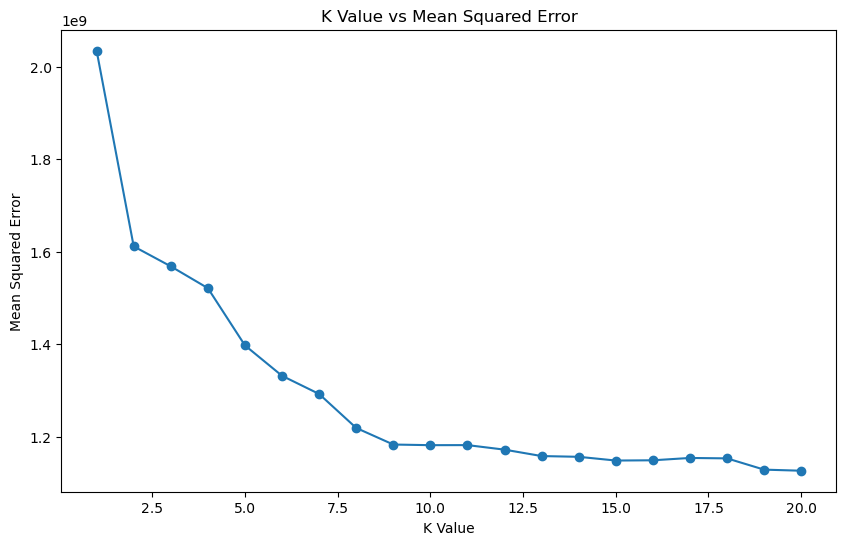

In [68]:
plt.figure(figsize=(10,6))
plt.plot(list(k_values), mse_values[:20], marker='o')
plt.xlabel('K Value')
plt.ylabel('Mean Squared Error')
plt.title('K Value vs Mean Squared Error')
plt.show()

In [69]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)
mse_lr=mean_squared_error(y_test,y_pred_lr)
print("Mean Squared Error for Linear Regression:", mse_lr)

Mean Squared Error for Linear Regression: 143079259.97919124


In [70]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
dt=DecisionTreeRegressor(random_state=42)
dt.fit(x_train,y_train)
y_pred_dt=dt.predict(x_test)
mse_dt=mean_squared_error(y_test,y_pred_dt)
print("Mean Squared Error for Decision Tree Regression:", mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print("R2 Score for Decision Tree Regression:", r2_dt)

Mean Squared Error for Decision Tree Regression: 525523511.1818703
R2 Score for Decision Tree Regression: 0.49628810439638804


In [71]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)
mse_lr=mean_squared_error(y_test,y_pred_lr)
print("Mean Squared Error for Linear Regression:", mse_lr)

Mean Squared Error for Linear Regression: 143079259.97919124


In [72]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R2 Score:", r2)

R2 Score: -0.07927304446759886
